In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Load data
df = pd.read_csv("data/online_news_cleaned.csv")

# Prepare features and target
y = df["log_shares"].to_numpy()
X = df.drop(columns=["shares", "log_shares"])
X = pd.get_dummies(X, drop_first=True)
feature_names = X.columns
X = X.to_numpy()

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression

# Train and evaluate Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
lr_mae = mean_absolute_error(y_test, y_pred)

print("Linear Regression RMSE:", lr_rmse)
print("Linear Regression MAE:", lr_mae)

Linear Regression RMSE: 0.8648576034715385
Linear Regression MAE: 0.6439770979847044


Best Ridge α: 483.2930238571752
Ridge RMSE: 0.8657065300119323
Ridge MAE: 0.6450126958075492

Top 20 Feature Importances:
kw_avg_avg                       0.346167
kw_max_avg                      -0.184296
data_channel_is_entertainment   -0.071889
LDA_00                           0.065922
kw_min_min                       0.059840
LDA_02                          -0.057167
average_token_length            -0.056818
data_channel_is_bus             -0.056503
global_subjectivity              0.051224
num_hrefs                        0.049280
data_channel_is_socmed           0.043346
is_weekend                       0.042171
data_channel_is_tech             0.041047
kw_avg_min                      -0.040166
kw_min_avg                      -0.035079
num_self_hrefs                  -0.033965
self_reference_min_shares        0.030685
weekday_is_saturday              0.030049
num_imgs                         0.029838
abs_title_subjectivity           0.029638
dtype: float64


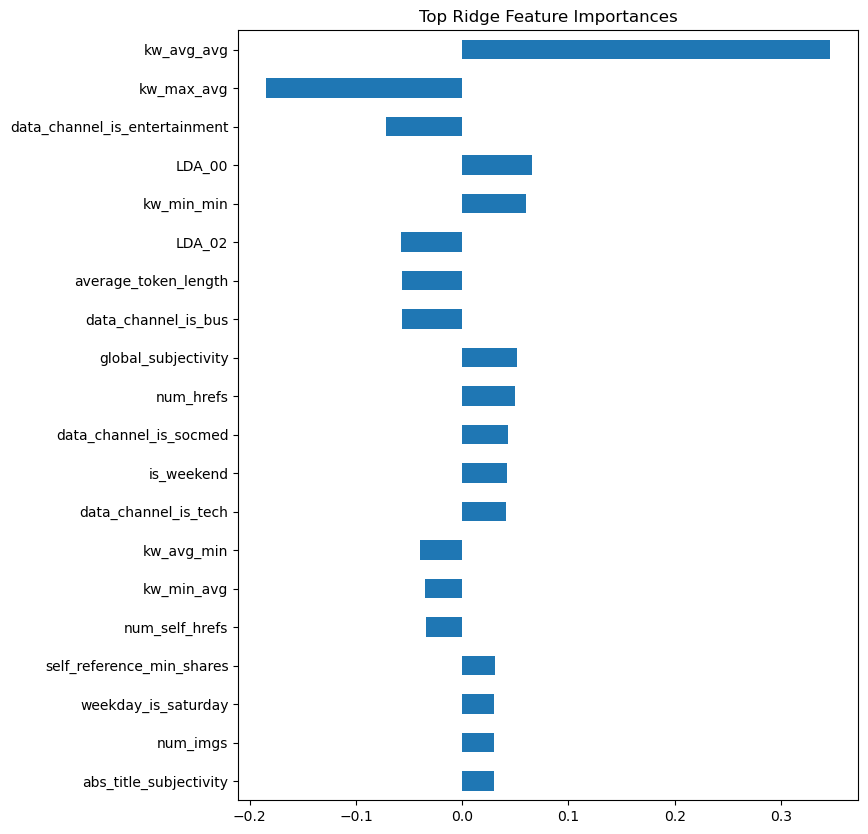

In [ ]:
from sklearn.linear_model import Ridge

# Train and evaluate Ridge Regression with hyperparameter tuning
alphas = np.logspace(-3, 3, 20)
ridge = Ridge()

# Set up GridSearchCV to find the best alpha
ridge_cv = GridSearchCV(
    ridge,
    {"alpha": alphas},
    scoring="neg_mean_squared_error",
    cv=5
)

ridge_cv.fit(X_train, y_train)

best_ridge_alpha = ridge_cv.best_params_["alpha"]
print("Best Ridge α:", best_ridge_alpha)

# Train Ridge with the best alpha
ridge_best = Ridge(alpha=best_ridge_alpha)
ridge_best.fit(X_train, y_train)

y_pred_ridge = ridge_best.predict(X_test)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)

print("Ridge RMSE:", ridge_rmse)
print("Ridge MAE:", ridge_mae)

# Feature importance for Ridge
coef = ridge_best.coef_
importance = pd.Series(coef, index=feature_names).sort_values(key=abs, ascending=False)

print("\nTop 20 Feature Importances:")
print(importance.head(20))

importance.head(20).plot(kind="barh", figsize=(8,10))
plt.title("Top Ridge Feature Importances")
plt.gca().invert_yaxis()
plt.show()

Best Lasso α: 0.001
Lasso RMSE: 0.8648404133813664
Lasso MAE: 0.644119268368759


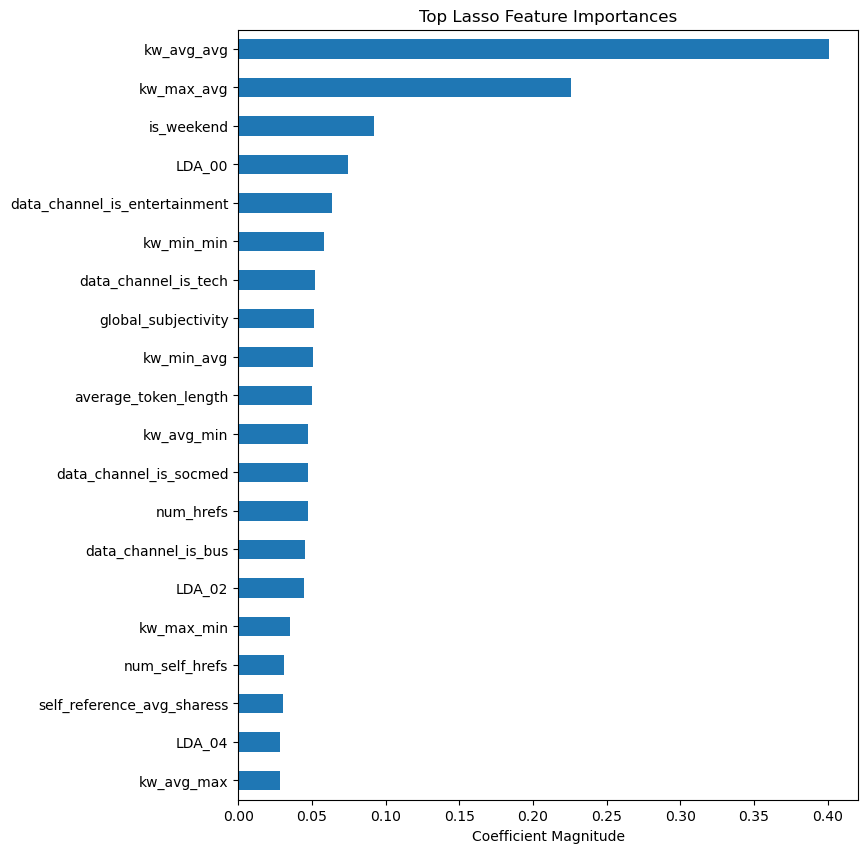

In [ ]:
from sklearn.linear_model import Lasso

# Train and evaluate Lasso Regression with hyperparameter tuning
lasso = Lasso(max_iter=5000)

# Set up GridSearchCV to find the best alpha
lasso_cv = GridSearchCV(
    lasso,
    {"alpha": alphas},
    scoring="neg_mean_squared_error",
    cv=5
)

lasso_cv.fit(X_train, y_train)

best_lasso_alpha = lasso_cv.best_params_["alpha"]
print("Best Lasso α:", best_lasso_alpha)

# Fit final Lasso model with best alpha
lasso_best = Lasso(alpha=best_lasso_alpha, max_iter=5000)
lasso_best.fit(X_train, y_train)

y_pred_lasso = lasso_best.predict(X_test)
lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
lasso_mae = mean_absolute_error(y_test, y_pred_lasso)

print("Lasso RMSE:", lasso_rmse)
print("Lasso MAE:", lasso_mae)

# Feature importance for Lasso
lasso_coef = pd.Series(lasso_best.coef_, index=feature_names)
top_lasso = lasso_coef.abs().sort_values(ascending=False).head(20)

plt.figure(figsize=(8,10))
top_lasso.sort_values().plot(kind="barh")
plt.title("Top Lasso Feature Importances")
plt.xlabel("Coefficient Magnitude")
plt.show()

In [ ]:
# Summary of results
results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge", "Lasso"],
    "RMSE": [lr_rmse, ridge_rmse, lasso_rmse],
    "MAE":  [lr_mae, ridge_mae, lasso_mae]
})

results

,Model,RMSE,MAE
0,Linear Regression,0.864858,0.643977
1,Ridge,0.865707,0.645013
2,Lasso,0.864840,0.644119


In [ ]:
from sklearn.decomposition import PCA

# Apply PCA and evaluate Linear Regression on PCA-transformed data
pca = PCA(n_components=0.95)   # keep 95% variance
X_pca = pca.fit_transform(X_scaled)

X_train_pca, X_test_pca, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

lr_pca = LinearRegression()
lr_pca.fit(X_train_pca, y_train)

y_pred_pca = lr_pca.predict(X_test_pca)
pca_rmse = np.sqrt(mean_squared_error(y_test, y_pred_pca))
pca_mae  = mean_absolute_error(y_test, y_pred_pca)

print("PCA Linear Regression RMSE:", pca_rmse)
print("PCA Linear Regression MAE:", pca_mae)

PCA Linear Regression RMSE: 0.8776017612580377
PCA Linear Regression MAE: 0.6550232124091047
